In [16]:
import pandas as pd
datos = pd.read_csv("puertos_vuelta2026_completo.csv")
datos.head()

,etapa,km_etapa,puerto,categoria,km_punto,rol
0,2,214.3,Alto Chateauneuf-Grasse,3a,44.7,intermedio
1,2,214.3,Col de Saint-Andrieu,3a,105.0,intermedio
2,3,174.0,Col de Mont Louis,1a,158.0,intermedio
3,3,174.0,Font Romeu,2a,174.0,final
4,4,104.8,Port de Envalira,1a,25.2,intermedio


In [17]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [18]:
pesos = {'Especial': 4, '1a': 3, '2a': 2, '3a': 1}
datos['peso'] = datos['categoria'].map(pesos)
datos['km_restantes'] = datos['km_etapa'] - datos['km_punto']
datos.head()

,etapa,km_etapa,puerto,categoria,km_punto,rol,peso,km_restantes
0,2,214.3,Alto Chateauneuf-Grasse,3a,44.7,intermedio,1,169.6
1,2,214.3,Col de Saint-Andrieu,3a,105.0,intermedio,1,109.3
2,3,174.0,Col de Mont Louis,1a,158.0,intermedio,3,16.0
3,3,174.0,Font Romeu,2a,174.0,final,2,0.0
4,4,104.8,Port de Envalira,1a,25.2,intermedio,3,79.6


In [19]:
final = datos[datos['rol'] == 'final'][['etapa', 'peso']].rename(columns={'peso':
'peso_final'})
intermedios = datos[datos['rol'] == 'intermedio']
peso_intermedios = intermedios.groupby('etapa')['peso'].sum().rename('peso_intermedios')
ultimo_ataque = intermedios.groupby('etapa')['km_restantes'].min().rename('km_ultimo_ataque')
semana = {4: 1, 7: 1, 9: 1, 12: 2, 14: 2, 19: 3, 20: 3}
bonus_semana_map = {1: 0, 2: 1, 3: 2}
resumen = pd.concat([final.set_index('etapa'), peso_intermedios, ultimo_ataque],
axis=1).fillna(0)
resumen['bonus_cercania'] = resumen['km_ultimo_ataque'].apply(lambda x: 2 if x < 40 else
(1 if x < 70 else 0))
resumen['bonus_semana'] = resumen.index.map(semana).map(bonus_semana_map)
resumen['puntuacion'] = (resumen['peso_final']*2 + resumen['peso_intermedios'] +
resumen['bonus_cercania'] + resumen['bonus_semana'])

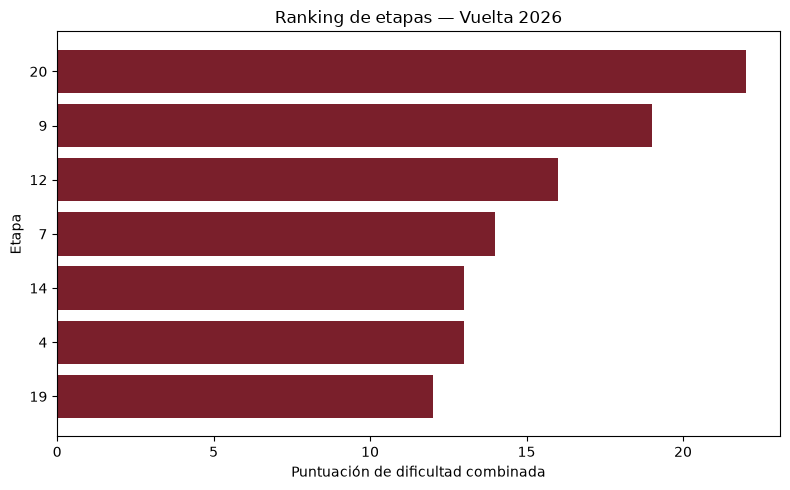

In [20]:
import matplotlib.pyplot as plt
ranking = resumen.sort_values('puntuacion', ascending=True)
plt.figure(figsize=(8,5))
plt.barh(ranking.index.astype(str), ranking['puntuacion'], color='#7a1f2b')
plt.xlabel('Puntuación de dificultad combinada')
plt.ylabel('Etapa')
plt.title('Ranking de etapas — Vuelta 2026')
plt.tight_layout()
plt.savefig('ranking_etapas.png', dpi=150)
plt.show()


Según mi índice de dificultad combinada, la etapa 20 es la máxima candidata a decidir La Vuelta 2026 con 22 puntos, por encima de la etapa 9 (Aitana, 19 pts) y la 12 (Calar Alto, 16 pts).

Aunque las etapas 9 y 20 concluyen en puertos de categoría Especial, la 20 marca la diferencia por dos factores clave:

Mayor desgaste previo: Encadena el doble paso por El Purche y Hazallanas antes del Collado del Alguacil.

Momento estratégico: Se disputa en la última semana, con tres semanas de fatiga acumulada en piernas y equipos.

Nota metodológica: Este índice evalúa criterios propios (categoría, dureza previa, distancia a meta y desgaste semanal). Es un análisis técnico razonado, no un modelo estadístico predictivo.